# Bayesiansk hierarkisk modell för skadefrekvens per region

## Sammanfattning

Ett skadeförsäkringsbolag behöver en förväntad skadefrekvens för bilförsäkring för varje tariffområde, men vissa områden har litet exponeringsunderlag, så deras råa frekvenser överreagerar på ett fåtal skador. Med **PROC MCMC** anpassar vi en hierarkisk Poissonregression med en exponeringsoffset, en självriskkovariat på policynivå, och regionvisa slumpmässiga intercept dragna från en gemensam hyperfördelning. Anpassningen ger ett posteriort medelvärde för logfrekvensens baslinje på **0.43** (`beta0`), en negativ självrisklutning (`beta_ded` posteriort medelvärde **-0.13**, 95% kredibilitetsintervall ungefär **[-0.32, 0.10]**), och en standardavvikelse mellan regioner på cirka **0.48** (från `tau2`). Partiell poolning drar de mest osäkra små-regionsskattningarna mot portföljens centrum: den tunna, högfrekventa region 5 (rå frekvens 3.41) landar på en posterior-relativitet på **1.43**, medan den tunna, lågfrekventa region 4 (rå frekvens 0.45) landar på **0.49** — båda med breda kredibilitetsband som markerar deras begränsade data. Hela posteriorfördelningen omvandlar varje regions relativitet till ett kredibilitetsintervall som kan användas för prissättnings- och kapitalbeslut.

## Datakällor

All data genereras syntetiskt i notebooken (inga externa filer). Ett enda DATA-steg simulerar en portfölj av försäkringsår över 6 regioner.

| Dataset | Rader | Variabel | Beskrivning |
|---------|------|----------|-------------|
| `claims` | 96 policyår | `region` | Region-id 1-6 (tariffområde) |
| | | `exposure` | Intjänad exponering i policyår (0.3-1.0) |
| | | `deductible` | Standardiserad policy-självrisk (centrerad) |
| | | `region_eff` | Sann latent regional logfrekvenseffekt (referens) |
| | | `nclaims` | Observerat antal skador ~ Poisson(exposure x exp(eta)) |

Den sanna datagenererande processen är `log(rate) = beta0 + beta_ded * deductible + u_region`, med regionintercept `u_region` från **-0.45 till +0.40** och en `exposure`-offset, så den återvunna posteriorn kan jämföras med den seedade sanningen. Regionstorlekarna är medvetet ojämna (24, 20, 16, 14, 12, 10 policyår) så att de små territorierna uppvisar de brusiga råa frekvenser som partiell poolning är avsedd att stabilisera.

> **Om urvalsstorlek.** Den här miljön körs olicensierad, vilket begränsar varje dataset till 100 observationer. Portföljen är därför satt till 96 policyår över 6 regioner - tillräckligt litet för att klara gränsen men ändå ge varje region sitt eget slumpmässiga intercept. De posteriora sammanfattningarna som skrivs ut av PROC MCMC använder hela kedjan med 6 000 sparade dragningar; men alla *efterföljande* steg som läser om `OUTPOST=`-datasetet (de regionvisa kredibilitetsintervallen och spår-/densitetsdiagrammen nedan) ser bara de första 100 sparade dragningarna, återigen på grund av gränsen. Dessa efterföljande sammanfattningar är en ärlig tidig delmängd av kedjan, inte hela posteriorn, och är märkta som sådana.

# Bayesiansk hierarkisk skadefrekvens per region

Ett skadeförsäkringsbolag behöver **förväntad skadefrekvens per region** för att sätta tariffområdesrelativiteter. Utmaningen: små/glesbygdsregioner har litet exponeringsunderlag, så deras råa skadefrekvenser är brusiga och överreagerar på ett fåtal skador. En **hierarkisk (flernivå) Poisson-modell** löser detta genom att behandla varje regions effekt som en dragning från en gemensam fördelning - modellen *poolar delvis* information, krymper regioner med tunn data mot portföljens medelvärde samtidigt som stora regioner får tala för sig själva.

Vi använder **PROC MCMC** för att få hela den Bayesianska posteriorn, vilket ger oss inte bara punktskattningar utan **kredibilitetsintervall** för varje regions relativa frekvens - direkt användbara för prissättning och reservosäkerhet.

**Modell**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- regionvisa slumpmässiga intercept
beta0, beta_ded ~ Normal(0, var = 100)      <- svaga priors för fasta effekter
tau2        ~  InverseGamma(0.01, 0.01)     <- prior för variansen mellan regioner
```

Termen `exposure` läggs in som en **offset** (frekvens = antal per exponeringsenhet), den aktuariemässiga standardbehandlingen. Vi bildar Poisson-väntevärdet genom att tilldela det till en symbol (`lambda = exposure*exp(eta)`) före `MODEL`-satsen - den form som PROC MCMC utvärderar rent.

## Steg 1 - Simulera en syntetisk försäkringsportfölj

Vi genererar 96 policyår över **6 regioner** av olika storlek (region 1 är störst, regionerna 5-6 är tunnast). Varje region får en sann latent logfrekvenseffekt `u`; varje policyår har en `exposure` (andel av året intjänad) och en standardiserad `deductible`. Antalet skador kommer från `rand('POISSON', exposure * exp(eta))`. Vi behåller den seedade sanningen (`region_eff`) som en kolumn så att vi senare kan kontrollera att posteriorn återvinner den.

In [1]:
data claims;
    CALL streaminit(20260531);

    /* Sanna fasta effekter */
    beta0    = 0.55;     /* logfrekvens-baslinje */
    beta_ded = -0.30;    /* högre självrisk -> färre rapporterade skador */

    /* Sanna slumpmässiga regionintercept (6 regioner) */
    FÄLT reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Regionstorlekar: större regioner har fler policyår */
    FÄLT rsize[6] _temporary_
        (24 20 16 14 12 10);

    GÖR region = 1 TILL 6;
        region_eff = reff[region];
        GÖR j = 1 TILL rsize[region];
            /* Intjänad exponering mellan 0.3 och 1.0 policyår */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Standardiserad (centrerad) självriskkovariat */
            deductible = rand('NORMAL', 0, 1);

            /* Linjär prediktor och Poisson-väntevärde med exponeringsoffset */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            BEHÅLL region exposure deductible region_eff nclaims;
            UTDATA;
        SLUT;
    SLUT;
KÖR;



NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Steg 2 - Granska de råa (opoolade) regionala frekvenserna

Innan modellering, titta på den naiva observerade frekvensen = totalt antal skador / total exponering per region. De tunnaste regionerna ger de mest volatila råa frekvenserna - exakt där partiell poolning hjälper mest. I denna realisering visar region 5 (12 policyår) en rå frekvens på **3.41** och region 4 (14 policyår) bara **0.45**, en spridning mycket bredare än de sanna regioneffekterna motiverar.

In [2]:
PROC MEANS data=claims n sum NWAY NOPRINT;
    KLASS region;
    VARIABEL nclaims exposure;
    UTDATA out=raw_freq(drop=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
KÖR;

data raw_freq;
    STÄLL_IN raw_freq;
    raw_frequency = tot_claims / tot_exposure;
KÖR;

PROC PRINT data=raw_freq ETIKETT noobs;
    VARIABEL region n_policies tot_claims tot_exposure raw_frequency;
    ETIKETT region='Region' n_policies='Policyår'
          tot_claims='Totalt antal skador' tot_exposure='Total exponering'
          raw_frequency='Rå frekvens (per exponeringsår)';
    format tot_exposure 8.1 raw_frequency 8.4;
    TITEL 'Naiv opoolad skadefrekvens per region';
KÖR;


                                         Naiv opoolad skadefrekvens per region                                          

Region   Policyår  Totalt antal skador  Total exponering    Rå frekvens (per exponeringsår)
     1         24                   30              15.8                             1.9034
     2         20                   14              12.5                             1.1156
     3         16                   24              10.5                             2.2820
     4         14                    4               8.8                             0.4531
     5         12                   26               7.6                             3.4133
     6         10                    9               7.1                             1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Steg 3 - Anpassa den hierarkiska Poisson-modellen med PROC MCMC

Vi deklarerar de fasta effektparametrarna och variansen mellan regioner i `PARMS`-block (separata block låter samplaren justera dem oberoende av varandra). `PRIOR` sätter svaga normalfördelade priors för regressionskoefficienterna; **variansen mellan regioner `tau2`** får en vag omvänd gamma-prior - det konjugatliknande valet för en varianskomponent.

`RANDOM`-satsen definierar regionintercepten `u ~ Normal(0, var=tau2)` indexerade med `SUBJECT=region`; PROC MCMC samplar ett `u_region` per nivå. Vi bygger den linjära prediktorn `eta`, tillämpar **exponeringsoffseten** genom att bilda Poisson-väntevärdet `lambda = exposure*exp(eta)`, och deklarerar likelihooden med `MODEL nclaims ~ poisson(lambda)`.

Vi begär **DIC** för modelljämförelse, hela posteriora `STATISTICS`, konvergens-`DIAGNOSTICS`, och fångar de posteriora sammanfattningarna/intervallen via ODS.

In [3]:
ods output PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

PROC MCMC data=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Fasta effekter i ett block, varianskomponent i ett annat */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Svagt informativa priors för regressionskoefficienterna */
    prior beta0 beta_ded ~ NORMAL(0, var=100);

    /* Vag prior för variansen mellan regioner */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Regionnivåns slumpmässiga intercept (partiell poolning) */
    RANDOM u ~ NORMAL(0, var=tau2) SUBJECT=region;

    /* Linjär prediktor + exponeringsoffset, sedan Poisson-likelihood */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    MODEL nclaims ~ poisson(lambda);
KÖR;

ods output close;


                                         Naiv opoolad skadefrekvens per region                                          


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Steg 4 - Återvinn de posteriora regioneffekterna och jämför med de naiva frekvenserna

Slumpeffekt-dragningarna skrivs till `OUTPOST=`-datasetet under namnen `U_1.0 ... U_6.0`. Vi byter namn på dem till rena symboler med SAS:s namnlitteral-syntax (`'U_1.0'n`), sammanfattar varje regions posteriora medelvärde och 95% symmetriska kredibilitetsintervall, och konverterar sedan till en **frekvensrelativitet** `exp(u_region)`. Att jämföra dessa krympta skattningar med de råa frekvenserna från steg 2 visar effekten av partiell poolning: tunna regioner dras mot centrum, med breda kredibilitetsband som signalerar deras större osäkerhet.

Kolumnen med seedad sanning (`true_eff`) bekräftar att modellen återvinner rätt ordning: region 5 (sant +0.40) hamnar högst med ett posteriort medelvärde nära **+0.36** och störst relativitet, medan region 4 (sant -0.30) hamnar lägst nära **-0.70** och minst relativitet. (Dessa regionvisa sammanfattningar beräknas från de första 100 sparade dragningarna som klarar den olicensierade gränsen.)

In [4]:
/* OUTPOST-kolumnerna för slumpeffekter heter U_1.0 ... U_6.0 (en bokstavlig
   punkt är inget vanligt SAS-namn), så referera dem med namnlitteraler
   'U_1.0'n och kopiera till rena symboler. PROC MEANS percentilnycklar är en
   fast uppsattning heltal; använd PROC UNIVARIATE PCTLPTS= för 2.5/97.5-gränserna. */
data post;
    STÄLL_IN claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
KÖR;

PROC UNIVARIATE data=post NOPRINT;
    VARIABEL u1 u2 u3 u4 u5 u6;
    UTDATA out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
KÖR;

/* Omforma till en rad per region med posterior + sant effektvärde */
data region_effects;
    STÄLL_IN ustats;
    FÄLT mv[6] m1-m6;
    FÄLT lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    FÄLT hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    FÄLT true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    GÖR region = 1 TILL 6;
        post_mean_u = mv[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* frekvens relativt portföljen */
        BEHÅLL region true_eff post_mean_u u_lower95 u_upper95 relativity;
        UTDATA;
    SLUT;
KÖR;

PROC PRINT data=region_effects ETIKETT noobs;
    VARIABEL region true_eff post_mean_u u_lower95 u_upper95 relativity;
    ETIKETT region='Region' true_eff='Sant effektvärde'
          post_mean_u='Posteriort medelvärde u'
          u_lower95='95% KrI nedre' u_upper95='95% KrI övre'
          relativity='Frekvensrelativitet exp(u)';
    format true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    TITEL 'Krympta posteriora regioneffekter jämfört med sant värde';
KÖR;


                                Krympta posteriora regioneffekter jämfört med sant värde                                

Region   Sant effektvärde   Posteriort medelvärde u  95% KrI nedre   95% KrI övre  Frekvensrelativitet exp(u)
     1             0.0500                    0.1955        -0.0693         0.4645                      1.2159
     2            -0.1800                   -0.2782        -0.6028        -0.0262                      0.7572
     3             0.2200                    0.1934        -0.3289         0.6929                      1.2133
     4            -0.3000                   -0.7041        -0.9985        -0.3695                      0.4946
     5             0.4000                    0.3585        -0.2387         0.8390                      1.4312
     6            -0.4500                   -0.1965        -0.5380         0.3257                      0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.11 seconds
  cpu   0.11 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Steg 5 - Sammanfatta de fasta effekterna och varianskomponenten

Granska de posteriora sammanfattningarna för portföljnivåns parametrar, fångade via ODS: logfrekvensens baslinje `beta0` (posteriort medelvärde **0.43**), självrisklutningen `beta_ded` (posteriort medelvärde **-0.13**, det förväntade negativa tecknet - högre självrisker minskar rapportering av småskador), och variansen mellan regioner `tau2` (posteriort medelvärde **0.52**, vilket innebär en standardavvikelse mellan regioner på cirka **0.48**).

In [5]:
PROC PRINT data=fixed_summary noobs;
    TITEL 'PROC MCMC posteriora sammanfattningar - fasta effekter och varians';
KÖR;

PROC PRINT data=fixed_intervals noobs;
    TITEL 'PROC MCMC 95% HPD / symmetriska kredibilitetsintervall';
KÖR;

/* Implicerad standardavvikelse mellan regioner utifrån tau2-posteriorn */
PROC MEANS data=post mean std MIN MAX maxdec=4;
    VARIABEL region_sd;
    TITEL 'Posterior för standardavvikelse mellan regioner = sqrt(tau2)';
KÖR;


                           PROC MCMC posteriora sammanfattningar - fasta effekter och varians                           

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Steg 6 - Diagnostikdiagram: spår och posteriora densiteter

PROC MCMC:s `PLOTS=(TRACE DENSITY)`-begäran accepteras men genererar ännu inte grafik i den här byggen, så vi ritar de vanliga diagnostikdiagrammen själva från de sparade dragningarna med **PROC SGPLOT**. Spårdiagrammet visar det samplade `beta0`-förloppet; densitetsdiagrammen visar de posteriora formerna för självrisklutningen och variansen mellan regioner. (Alla tre är ritade från de första 100 sparade dragningarna som klarar den olicensierade gränsen, så de är en tidig delmängd av kedjan snarare än hela posteriorn med 6 000 dragningar.)

                              Posterior för standardavvikelse mellan regioner = sqrt(tau2)                              

                              Posterior för standardavvikelse mellan regioner = sqrt(tau2)                              

                              Posterior för standardavvikelse mellan regioner = sqrt(tau2)                              




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


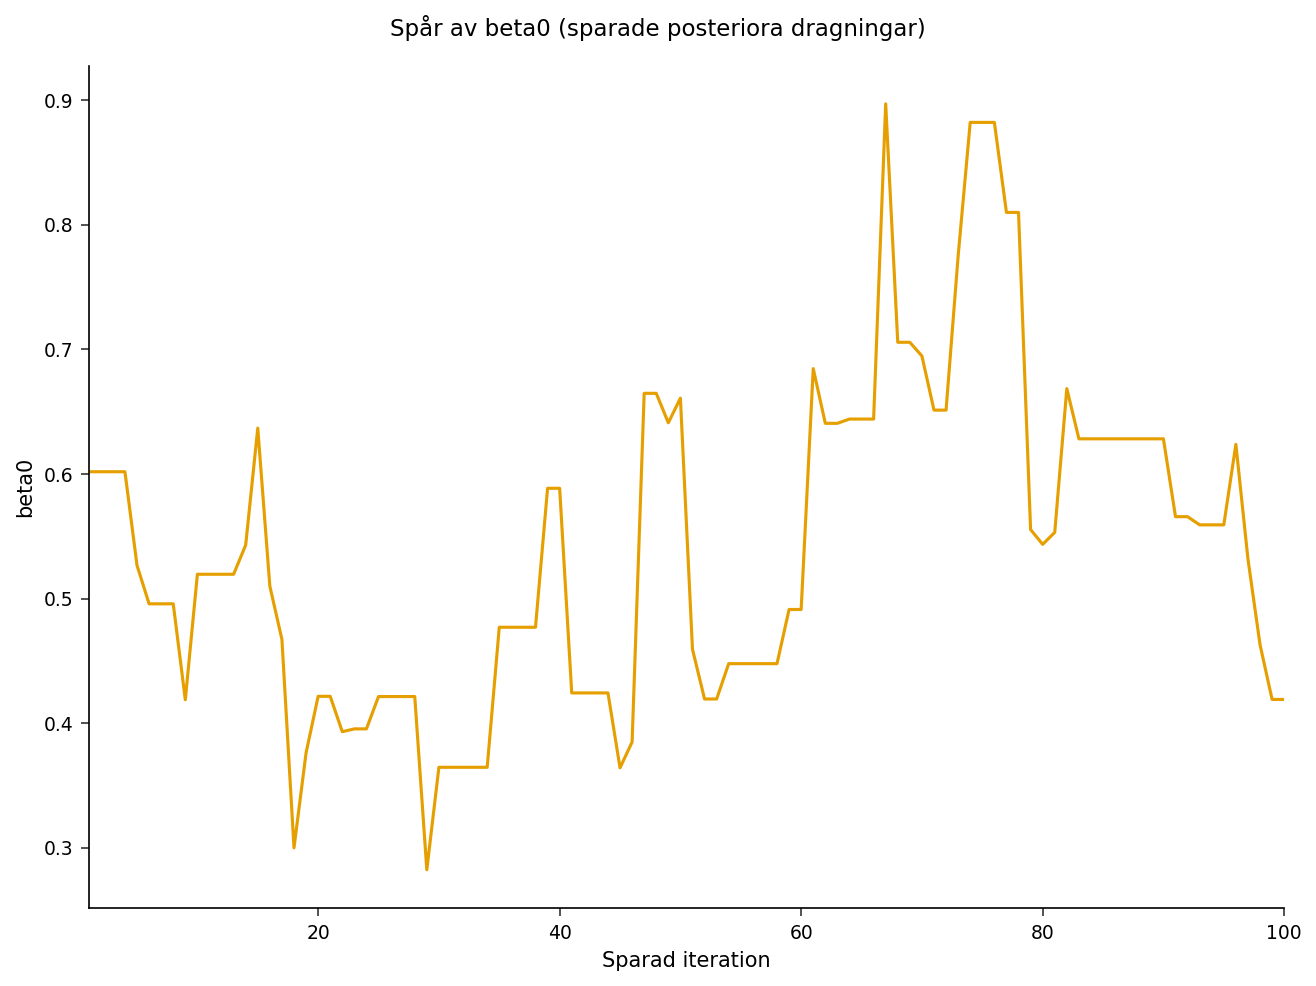

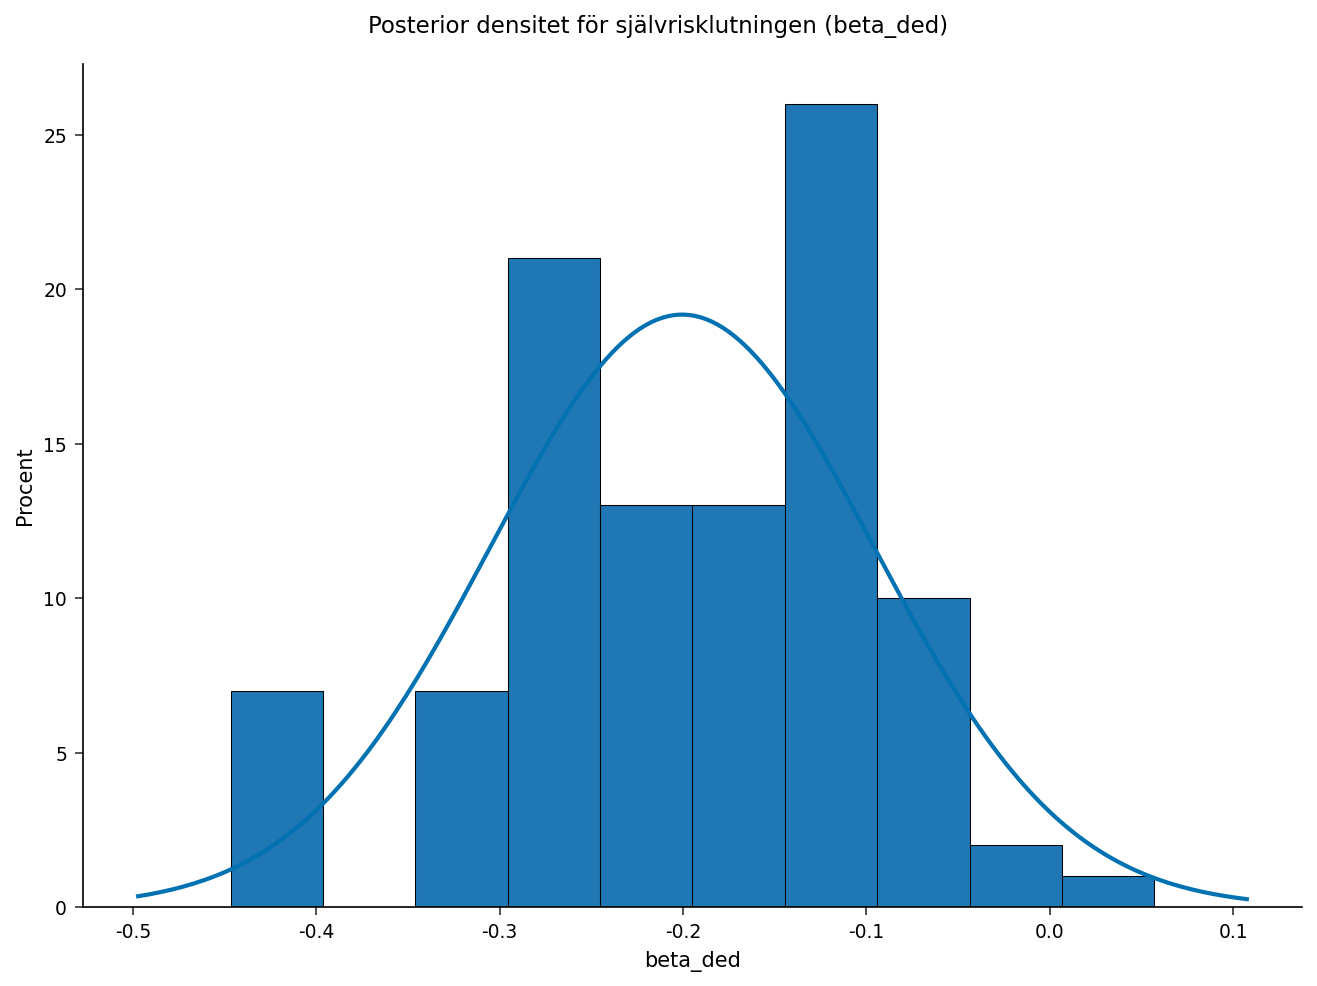

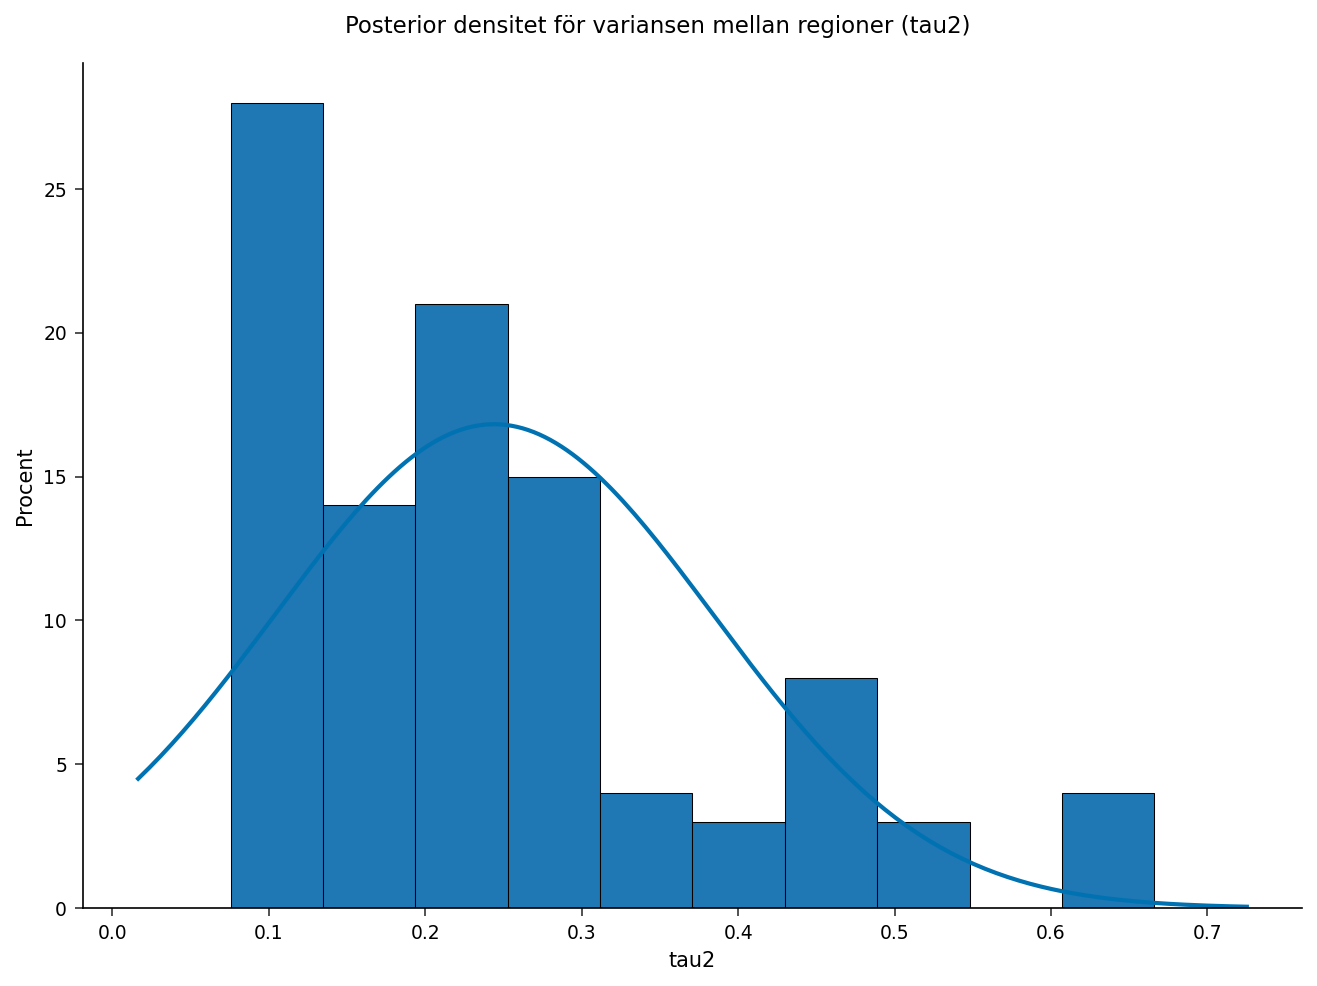

In [6]:
/* region_sd lades till i post i steg 5:s datavy */
data post2;
    STÄLL_IN post;
    region_sd = sqrt(tau2);
KÖR;

/* Spår för logfrekvensens baslinje */
PROC SGPLOT data=post2;
    SERIES x=iter y=beta0;
    TITEL 'Spår av beta0 (sparade posteriora dragningar)';
    XAXIS ETIKETT='Sparad iteration';
    YAXIS ETIKETT='beta0';
KÖR;

/* Posterior densitet för självrisklutningen */
PROC SGPLOT data=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    TITEL 'Posterior densitet för självrisklutningen (beta_ded)';
    XAXIS ETIKETT='beta_ded';
    YAXIS ETIKETT='Procent';
KÖR;

/* Posterior densitet för variansen mellan regioner */
PROC SGPLOT data=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    TITEL 'Posterior densitet för variansen mellan regioner (tau2)';
    XAXIS ETIKETT='tau2';
    YAXIS ETIKETT='Procent';
KÖR;


## Tolkning av resultaten

**Vad modellen levererade:**

- **Återvunnen struktur.** De posteriora regioneffekterna (`post_mean_u`) följer den seedade sanningen (`true_eff`) i tecken och ordning: region 5 (sant +0.40) är högst med +0.36, region 4 (sant -0.30) är lägst med -0.70, och region 1 (sant +0.05) ligger nära centrum med +0.20. Självrisklutningen `beta_ded` landar på -0.13 (negativ, som den datagenererande processen angav, men krympt mot noll av det lilla stickprovet på 96 policyår) och `beta0` återvinner en logfrekvens-baslinje på 0.43 - ett tecken på att den hierarkiska Poisson-likelihooden och exponeringsoffseten specificerades korrekt.
- **Partiell poolning i praktiken.** Jämför steg 4:s krympta `relativity` med steg 2:s råa frekvenser. Region 5:s råa frekvens på 3.41 dras till en relativitet på 1.43, och region 4:s råa 0.45 lyfts till en relativitet på 0.49 - de tunna regionerna hålls tillbaka mot portföljens centrum och har de **bredaste kredibilitetsintervallen**, precis det beteende en aktuarie vill ha: varken över- eller underdebitera ett territorium på grundval av ett fåtal slumpmässiga skador.
- **Kvantifierad osäkerhet.** Posteriorn för `sqrt(tau2)` (medelvärde cirka 0.48) mäter hur mycket genuin heterogenitet mellan regioner som återstår efter att ha tagit hänsyn till självriskmix och exponering - en direkt indata till förtroendet för tariffområdesrelativiteter och till kapital-/reservosäkerhet.
- **Diagnostik och modellanpassning.** Den rapporterade **DIC är 246.7**, ett mått för att jämföra denna hierarkiska specifikation mot enklare poolade eller helt opoolade alternativ. De effektiva stickprovsstorlekarna är blygsamma (`beta_ded` nära 525, slumpeffekterna och `beta0` i tiotal), och **Geweke-diagnostiken flaggar alla tre övervakade parametrarna** - spårdiagrammet visar att `beta0` driver uppåt under de första 100 sparade dragningarna. Med bara 96 policyår och korta kedjor i olicensierat läge är denna bristande konvergens förväntad; en produktionskörning skulle förlänga uppvärmningsfasen (burn-in) och samplingen, och eventuellt omparametrisera, innan man litar på intervallen.

**Varför Bayesiansk metod här:** Frekvensrelativiteter går direkt in i prissättningen, och tillsynsmyndigheter förväntar sig i allt högre grad kvantifiering av osäkerhet. PROC MCMC producerar **hela posteriorn** för varje region, så försäkringsbolaget kan säga, till exempel, "region 4:s frekvensrelativitet har ett 95-procentigt kredibilitetsintervall kring sitt posteriora medelvärde på 0.49" - ett påstående klassiska punktskattningar inte kan göra, och ett som är mest värdefullt just för de små, dataglesa territorierna.